In [1]:
import pandas as pd

prices = pd.read_csv(
    "../data/prices.csv",
    index_col=0,
    parse_dates=True
)

prices.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267078,136.742554,59.450500,88.292404,282.886383,131.293930,102.634377,30.269539,88.640495,106.224525,...,78.699928,56.421844,4.922529,72.280716,127.825645,110.094933,191.993881,107.888252,33.712955,28.800240
2018-01-03,40.260059,139.322906,60.209999,88.836777,283.801239,131.494537,103.499397,30.511000,89.286644,106.680595,...,79.066162,56.412956,5.246499,72.192986,128.338547,110.445290,194.007904,108.962334,33.020176,29.051458
2018-01-04,40.447075,138.735779,60.479500,90.314392,282.724426,133.300400,104.865761,30.597322,89.008736,106.633095,...,79.762054,56.377411,5.274156,72.703316,127.640266,110.445290,194.850021,109.367455,33.127251,29.077751
2018-01-05,40.907562,139.562393,61.457001,90.520370,294.322327,135.407333,106.261620,31.021097,88.862816,106.053505,...,80.750977,56.857292,5.318850,72.751152,130.285141,110.245094,198.565643,111.986710,33.051670,29.250097
2018-01-08,40.755630,139.523788,62.343498,89.687523,295.570770,138.810043,107.008705,31.342834,89.300545,104.533295,...,80.833328,57.363838,5.481823,73.133873,131.008133,109.652832,195.119171,112.438950,32.994991,29.682444


In [2]:
returns = prices.pct_change()

returns.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.018870,0.012775,0.006166,0.003234,0.001528,0.008428,0.007977,0.007290,0.004293,...,0.004654,-0.000158,0.065814,-0.001214,0.004013,0.003182,0.010490,0.009955,-0.020549,0.008723
2018-01-04,0.004645,-0.004214,0.004476,0.016633,-0.003794,0.013733,0.013202,0.002829,-0.003113,-0.000445,...,0.008801,-0.000630,0.005271,0.007069,-0.005441,0.000000,0.004341,0.003718,0.003243,0.000905
2018-01-05,0.011385,0.005958,0.016163,0.002281,0.041022,0.015806,0.013311,0.013850,-0.001639,-0.005435,...,0.012398,0.008512,0.008474,0.000658,0.020721,-0.001813,0.019069,0.023949,-0.002282,0.005927
2018-01-08,-0.003714,-0.000277,0.014425,-0.009201,0.004242,0.025129,0.007031,0.010372,0.004926,-0.014334,...,0.001020,0.008909,0.030641,0.005261,0.005549,-0.005372,-0.017357,0.004038,-0.001715,0.014781


<Axes: >

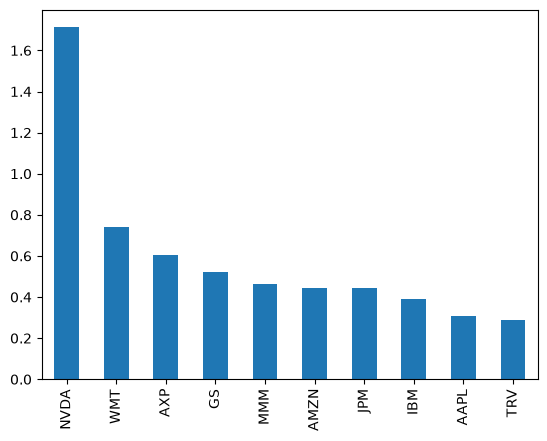

In [6]:
momentum = prices.pct_change(252)
latest_momentum = momentum.iloc[-1]

latest_momentum.sort_values(
    ascending=False
)
top10 = latest_momentum.sort_values(
    ascending=False
).head(10)

top10.plot(kind="bar")

In [7]:
rankings = (
    latest_momentum
    .sort_values(ascending=False)
    .reset_index()
)

rankings.columns = [
    "Ticker",
    "Momentum"
]

rankings.to_csv(
    "../data/momentum_rankings.csv",
    index=False
)

<Axes: >

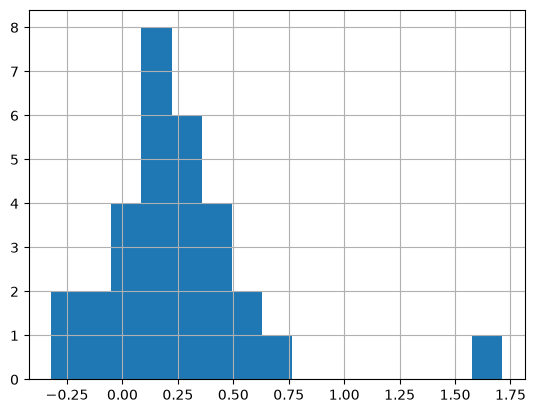

In [8]:
latest_momentum.hist(
    bins=15
)

In [9]:
from scipy.stats import zscore

momentum_z = pd.Series(
    zscore(latest_momentum),
    index=latest_momentum.index
)

momentum_z.sort_values(
    ascending=False
)

NVDA    4.066538
WMT     1.381600
AXP     1.004157
GS      0.775331
MMM     0.612261
AMZN    0.564449
JPM     0.561568
IBM     0.423047
AAPL    0.186590
TRV     0.132845
CRM     0.105383
CAT     0.019664
DIS     0.013704
V      -0.044945
CSCO   -0.081460
PG     -0.184760
HD     -0.247097
VZ     -0.298256
MSFT   -0.304199
HON    -0.384581
SHW    -0.387768
KO     -0.416000
CVX    -0.625546
MCD    -0.657307
UNH    -0.727621
JNJ    -0.793907
MRK    -0.833898
AMGN   -0.848029
NKE    -1.464637
BA     -1.547126
dtype: float64